# Jupyter Notebooks

**Introduction**

In [ ]:
# Instructor Effectiveness Modeling (EdTech Context)

## Problem Statement

This project aims to estimate instructor effectiveness using learner performance, engagement, and feedback data from an EdTech platform. Each row in the dataset represents a course batch, and instructors may teach multiple batches across different courses.

Since instructor effectiveness is not explicitly provided, we will define a custom effectiveness score using available metrics, aggregate batch-level information to the instructor level, and build a machine learning model to predict instructor effectiveness tiers.

## Objectives

- Perform Exploratory Data Analysis (EDA)
- Define an Instructor Effectiveness Score
- Aggregate batch-level data into instructor-level features
- Build a classification model to predict instructor effectiveness
- Evaluate model performance
- Interpret results and discuss business implications

## Dataset Overview

The dataset contains information related to:

- Learner outcomes
- Student engagement
- Learner feedback
- Course and instructor identifiers

Each record represents one course batch taught by an instructor.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Plot settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [2]:
# Load dataset
df = pd.read_excel("/content/instructor_effectiveness_dataset_2000_rows.xlsx")

# Display first five rows
df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [3]:
# Shape of dataset
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Data types
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (2000, 12)

Columns:
['batch_id', 'instructor_id', 'course_id', 'completion_rate', 'avg_score_improvement', 'avg_quiz_score', 'dropout_rate', 'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate', 'avg_feedback_score', 'feedback_response_rate']

Data Types:
batch_id                       object
instructor_id                  object
course_id                      object
completion_rate               float64
avg_score_improvement         float64
avg_quiz_score                float64
dropout_rate                  float64
avg_watch_time                float64
assignment_submission_rate    float64
forum_activity_rate           float64
avg_feedback_score            float64
feedback_response_rate        float64
dtype: object


In [4]:
# Summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
completion_rate,2000.0,0.602808,0.159667,0.300000,0.489260,0.603091,0.712797,0.980000
avg_score_improvement,2000.0,27.035844,5.716641,6.159240,23.124673,26.938629,30.885600,40.000000
avg_quiz_score,2000.0,77.956126,10.695618,40.386725,70.897590,78.020567,85.444286,100.000000
dropout_rate,2000.0,0.394883,0.162747,0.020000,0.280035,0.394820,0.511432,0.700000
avg_watch_time,2000.0,0.776515,0.145231,0.287440,0.675076,0.780330,0.894242,1.000000
assignment_submission_rate,2000.0,0.753188,0.148058,0.251111,0.652110,0.756380,0.856458,1.000000
forum_activity_rate,2000.0,0.250300,0.100640,0.000000,0.179845,0.249771,0.319204,0.641111
avg_feedback_score,2000.0,4.207134,0.419209,2.639915,3.918986,4.205989,4.503437,5.000000
feedback_response_rate,2000.0,0.736519,0.149412,0.259935,0.633293,0.737213,0.845876,1.000000


In [5]:
# Missing values
missing = df.isnull().sum()

missing

,0
batch_id,0
instructor_id,0
course_id,0
completion_rate,0
avg_score_improvement,0
avg_quiz_score,0
dropout_rate,0
avg_watch_time,0
assignment_submission_rate,0
forum_activity_rate,0


### Observation

The dataset does not contain missing values, indicating that it is complete and ready for further analysis without requiring imputation.

In [6]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


### Observation

The dataset contains **no duplicate records**, indicating that each course batch is uniquely represented. This ensures that the analysis and model training will not be biased by repeated observations.

# **Exploratory Data Analysis**

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand the distribution, variability, and relationships among the variables. In this section, we analyze the numerical features to identify patterns, detect anomalies, and gain insights that will guide feature engineering and model building.

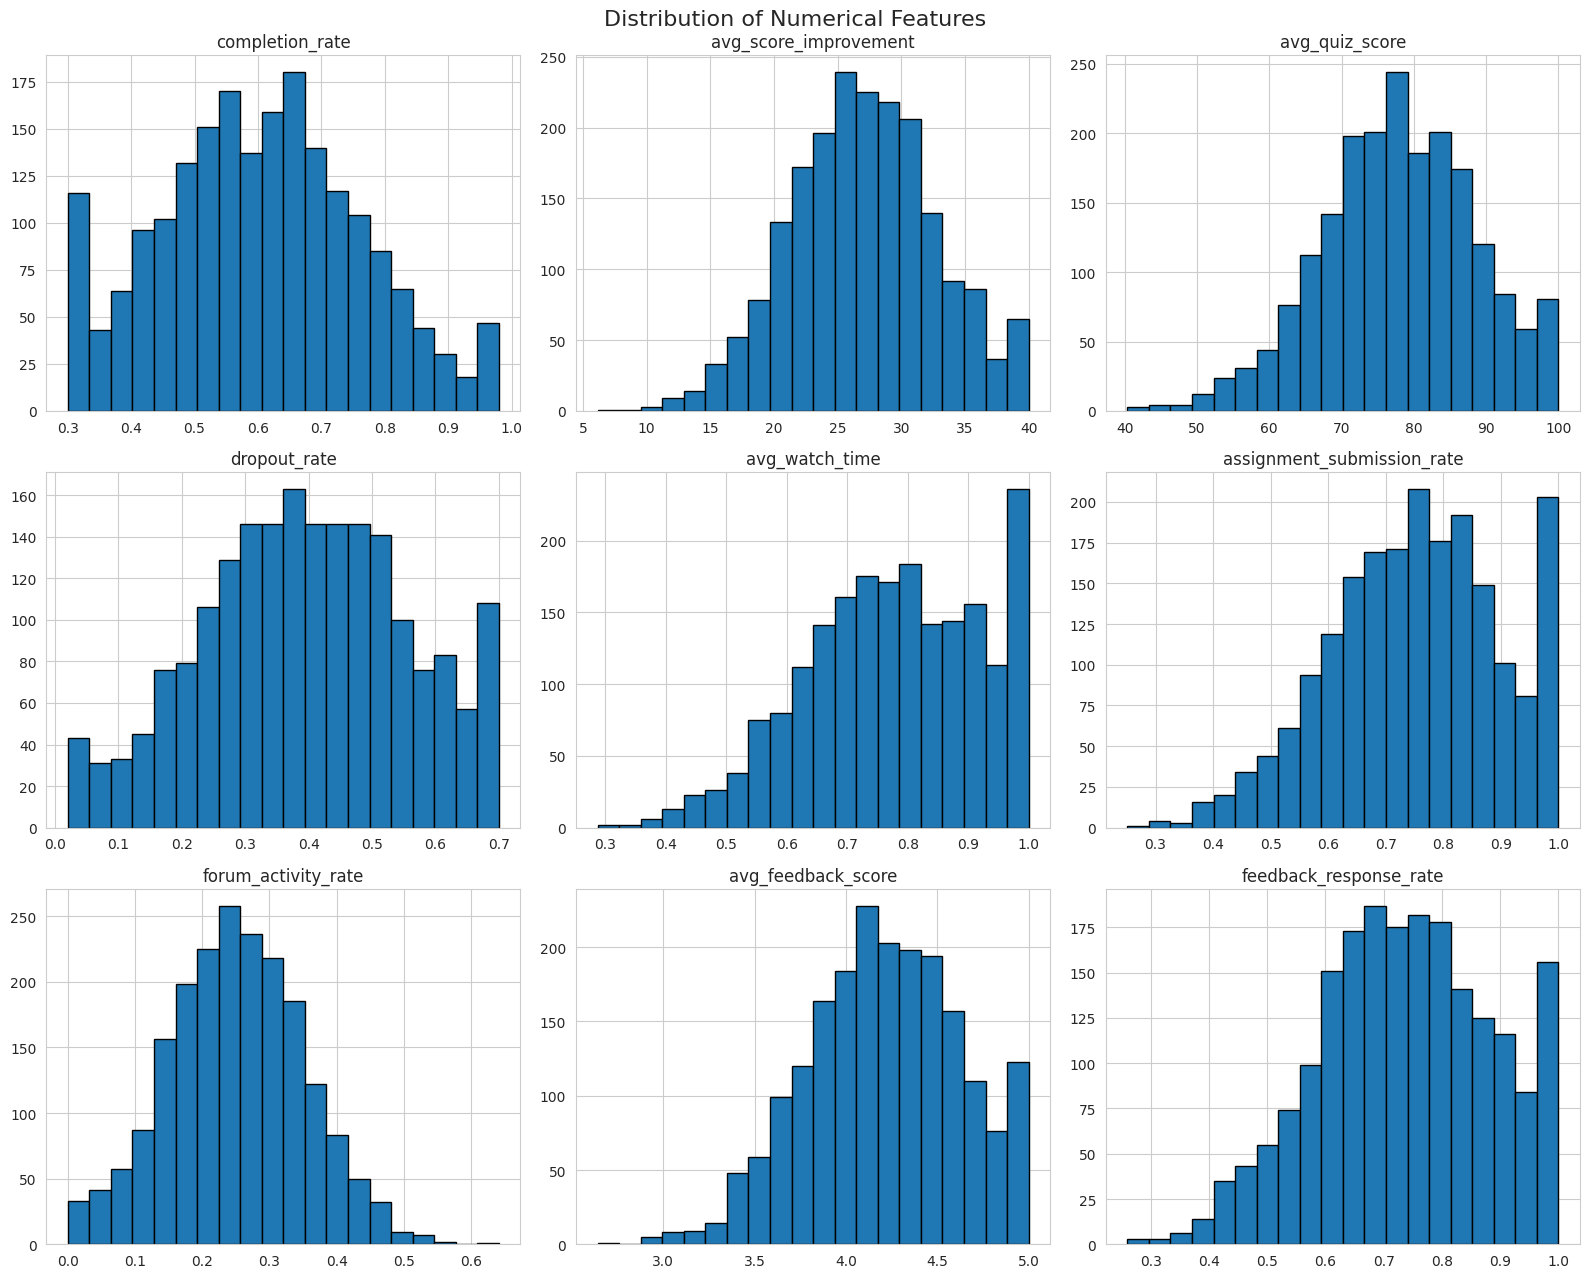

In [8]:
# Select numerical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Plot histograms
df[numerical_cols].hist(
    figsize=(16, 13),
    bins=20,
    edgecolor='black'
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

### Observations

- Most numerical features show continuous distributions with varying degrees of spread.
- Completion rate and dropout rate appear bounded between 0 and 1, as expected.
- Feedback scores are concentrated within a relatively narrow range, indicating generally consistent learner ratings.
- No obvious abnormal distributions are observed, though some features may exhibit slight skewness.

### Outlier Detection

Boxplots help identify potential outliers and understand the spread of each numerical variable. Detecting outliers is important because extreme values may influence model performance.

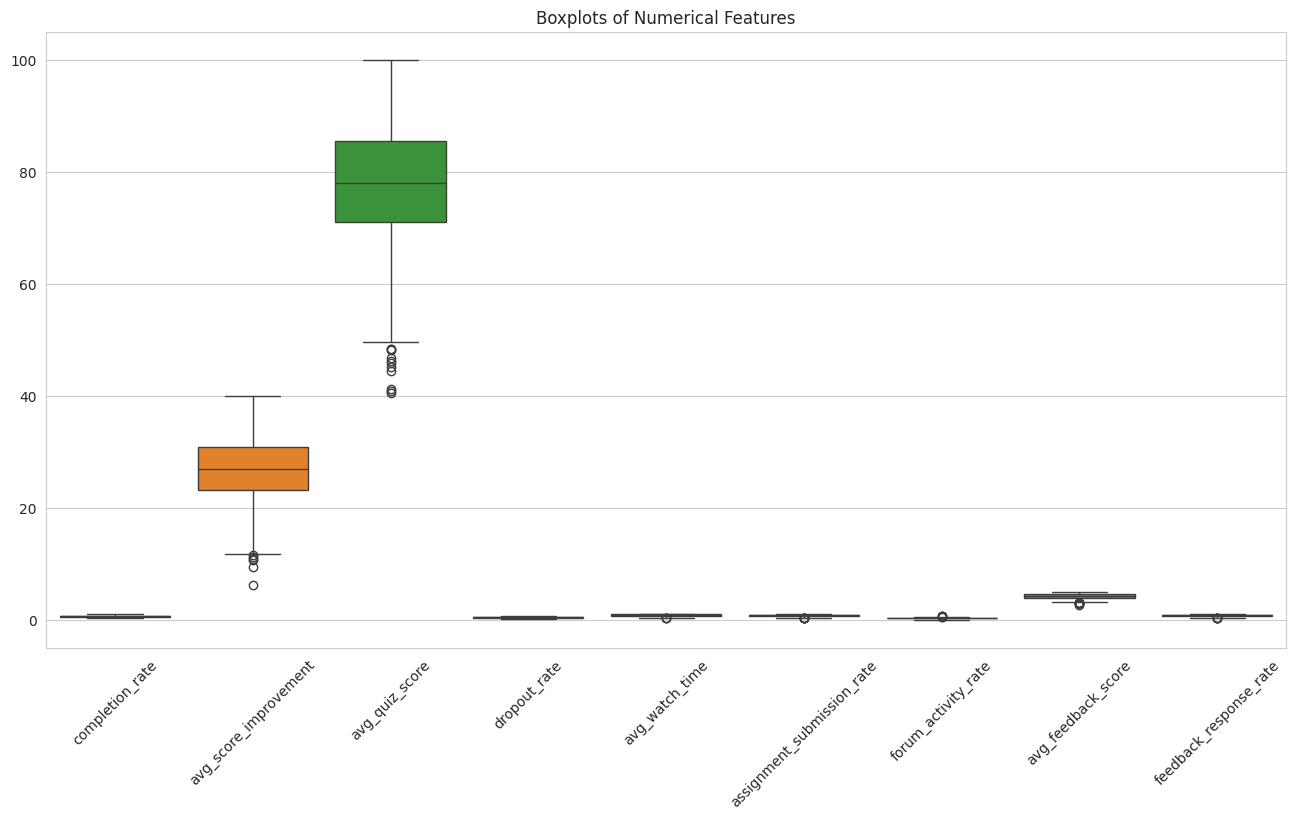

In [9]:
plt.figure(figsize=(16,8))

sns.boxplot(data=df[numerical_cols])

plt.xticks(rotation=45)
plt.title("Boxplots of Numerical Features")
plt.show()

### Observations

- Most variables have a reasonable spread with limited extreme values.
- Since the dataset represents real educational outcomes, these values may reflect genuine differences between course batches rather than data errors.
- Therefore, no outliers will be removed at this stage.

### Correlation Analysis

The correlation heatmap helps identify relationships between variables and highlights features that may positively or negatively influence instructor effectiveness.

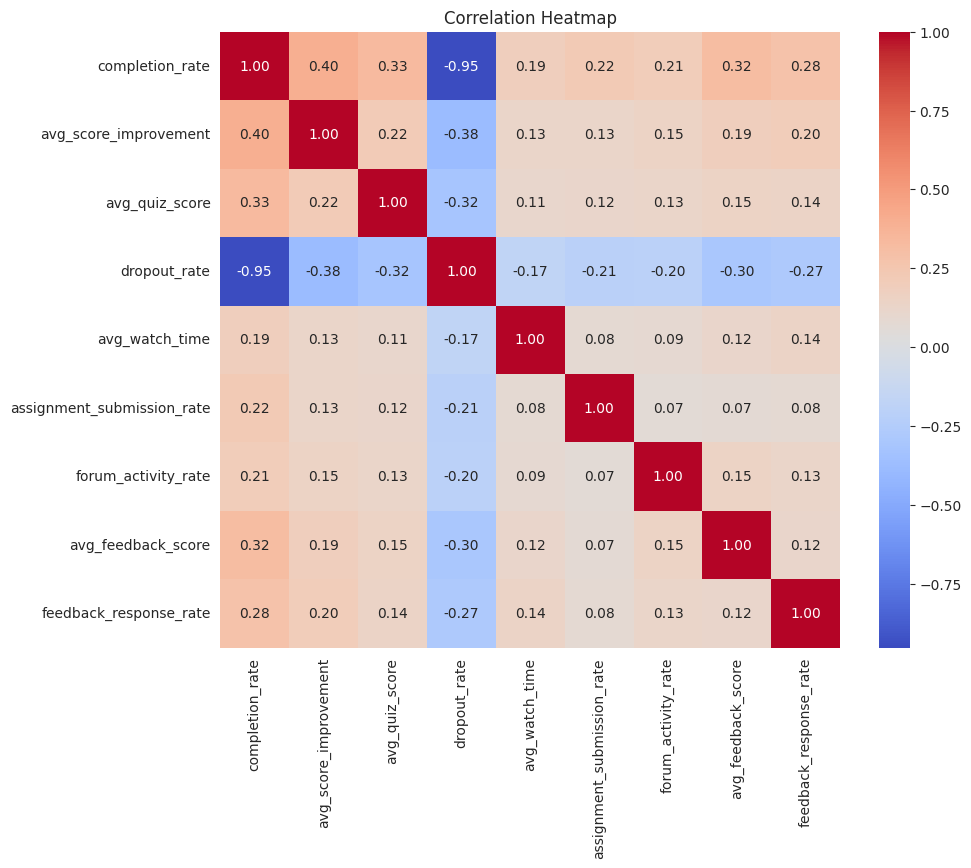

In [10]:
plt.figure(figsize=(10,8))

corr = df[numerical_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

### Observations

From the correlation heatmap, the following key relationships are observed:

- **Completion rate and dropout rate** have a very strong negative correlation (**-0.95**), indicating that batches with higher completion rates tend to have significantly lower dropout rates.
- **Average score improvement** has a moderate positive correlation (**0.40**) with completion rate, suggesting that learners who complete the course generally show greater learning gains.
- **Average quiz score** is positively correlated with completion rate (**0.33**), indicating better academic performance in batches with higher completion.
- **Average feedback score** also shows a positive relationship (**0.32**) with completion rate, suggesting that satisfied learners are more likely to complete the course.
- Engagement metrics such as **average watch time**, **assignment submission rate**, and **forum activity rate** have relatively weak positive correlations with learner outcomes, indicating that while engagement contributes to success, it is not the sole determining factor.

Overall, the analysis suggests that learner completion, academic improvement, and feedback are likely to be important indicators of instructor effectiveness.

# **Define Instructor Effectiveness**

# Defining Instructor Effectiveness

The dataset does not contain a predefined measure of instructor effectiveness. Therefore, an Instructor Effectiveness Score is created using a weighted combination of learner outcome, engagement, and feedback metrics.

The weights are assigned based on their expected contribution to effective teaching.

| Metric | Weight | Reason |
|---------|--------|--------|
| Completion Rate | 25% | Indicates successful course completion |
| Dropout Rate | -15% | Lower dropout reflects better teaching effectiveness |
| Average Score Improvement | 20% | Measures actual learning gain |
| Average Quiz Score | 10% | Reflects learner understanding |
| Average Watch Time | 10% | Indicates learner engagement |
| Assignment Submission Rate | 8% | Shows active participation |
| Forum Activity Rate | 5% | Represents collaborative engagement |
| Average Feedback Score | 5% | Captures learner satisfaction |
| Feedback Response Rate | 2% | Reflects reliability of feedback collected |

The weighted score is then used to categorize instructors into three effectiveness tiers: **Low**, **Medium**, and **High**.

In [11]:
# Create Instructor Effectiveness Score

df['effectiveness_score'] = (
    0.25 * df['completion_rate']
    - 0.15 * df['dropout_rate']
    + 0.20 * df['avg_score_improvement']
    + 0.10 * (df['avg_quiz_score'] / 100)
    + 0.10 * df['avg_watch_time']
    + 0.08 * df['assignment_submission_rate']
    + 0.05 * df['forum_activity_rate']
    + 0.05 * (df['avg_feedback_score'] / 5)
    + 0.02 * df['feedback_response_rate']
)

df[['effectiveness_score']].head()

,effectiveness_score
0,3.091101
1,4.960163
2,3.488594
3,5.266722
4,6.601192


In [12]:
df['effectiveness_score'].describe()

,effectiveness_score
count,2000.000000
mean,5.783818
std,1.178860
min,1.592881
25%,4.971099
50%,5.770402
75%,6.563889
max,8.586459


In [13]:
# Create Effectiveness Tiers

df['effectiveness_tier'] = pd.qcut(
    df['effectiveness_score'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

df[['effectiveness_score','effectiveness_tier']].head()

,effectiveness_score,effectiveness_tier
0,3.091101,Low
1,4.960163,Low
2,3.488594,Low
3,5.266722,Low
4,6.601192,High


In [14]:
# Check distribution of classes

df['effectiveness_tier'].value_counts()

,count
effectiveness_tier,
Low,667
High,667
Medium,666


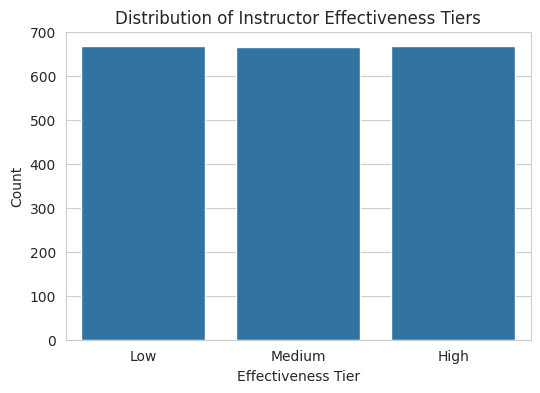

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='effectiveness_tier',
    data=df,
    order=['Low','Medium','High']
)

plt.title("Distribution of Instructor Effectiveness Tiers")
plt.xlabel("Effectiveness Tier")
plt.ylabel("Count")

plt.show()

### Observation

The effectiveness scores are divided into three approximately equal groups using quantile-based binning. This produces a balanced target variable, reducing the risk of class imbalance during model training and ensuring that each effectiveness tier is adequately represented.

# **Aggregate Batch-Level Data to Instructor-Level**

## Aggregating Batch-Level Data to Instructor-Level

Each row in the dataset represents a course batch, whereas the objective is to evaluate instructors.

Therefore, batch-level metrics are aggregated to the instructor level.

### Aggregation Strategy

- **Mean** is used for learner outcome, engagement, and feedback metrics because it represents the instructor's overall performance across batches.
- **Count of batches** represents teaching experience on the platform.
- **Number of unique courses** captures the diversity of subjects taught by an instructor.

This aggregation provides a more comprehensive representation of instructor performance than relying on individual batches.

In [17]:
# Aggregate data at instructor level

instructor_df = df.groupby('instructor_id').agg({

    'completion_rate':'mean',
    'dropout_rate':'mean',
    'avg_score_improvement':'mean',
    'avg_quiz_score':'mean',
    'avg_watch_time':'mean',
    'assignment_submission_rate':'mean',
    'forum_activity_rate':'mean',
    'avg_feedback_score':'mean',
    'feedback_response_rate':'mean',

    'batch_id':'count',
    'course_id':'nunique',

    'effectiveness_score':'mean'

}).reset_index()

In [18]:
instructor_df.rename(columns={

    'batch_id':'total_batches',
    'course_id':'unique_courses'

}, inplace=True)

instructor_df.head()

,instructor_id,completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,total_batches,unique_courses,effectiveness_score
0,I_001,0.543887,0.470593,26.641462,78.900194,0.766513,0.726893,0.240551,4.217743,0.694858,25,16,5.675480
1,I_002,0.730874,0.247194,30.166242,81.737198,0.837393,0.774394,0.289610,4.343002,0.784338,20,10,6.479913
2,I_003,0.768447,0.234828,29.977813,81.590928,0.818441,0.779606,0.296224,4.450034,0.812132,18,14,6.453808
3,I_004,0.458328,0.547261,22.912021,77.680317,0.793130,0.758317,0.226259,4.076410,0.721460,17,10,4.899062
4,I_005,0.859747,0.145733,32.588652,85.828159,0.847026,0.876942,0.333519,4.202516,0.784197,19,13,7.025878


In [19]:
# Create instructor effectiveness tier

instructor_df['effectiveness_tier'] = pd.qcut(

    instructor_df['effectiveness_score'],

    q=3,

    labels=['Low','Medium','High']

)

instructor_df.head()

,instructor_id,completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,total_batches,unique_courses,effectiveness_score,effectiveness_tier
0,I_001,0.543887,0.470593,26.641462,78.900194,0.766513,0.726893,0.240551,4.217743,0.694858,25,16,5.675480,Medium
1,I_002,0.730874,0.247194,30.166242,81.737198,0.837393,0.774394,0.289610,4.343002,0.784338,20,10,6.479913,High
2,I_003,0.768447,0.234828,29.977813,81.590928,0.818441,0.779606,0.296224,4.450034,0.812132,18,14,6.453808,High
3,I_004,0.458328,0.547261,22.912021,77.680317,0.793130,0.758317,0.226259,4.076410,0.721460,17,10,4.899062,Low
4,I_005,0.859747,0.145733,32.588652,85.828159,0.847026,0.876942,0.333519,4.202516,0.784197,19,13,7.025878,High


In [20]:
print("Instructor-level Dataset Shape:", instructor_df.shape)

instructor_df.head()

Instructor-level Dataset Shape: (120, 14)


,instructor_id,completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,total_batches,unique_courses,effectiveness_score,effectiveness_tier
0,I_001,0.543887,0.470593,26.641462,78.900194,0.766513,0.726893,0.240551,4.217743,0.694858,25,16,5.675480,Medium
1,I_002,0.730874,0.247194,30.166242,81.737198,0.837393,0.774394,0.289610,4.343002,0.784338,20,10,6.479913,High
2,I_003,0.768447,0.234828,29.977813,81.590928,0.818441,0.779606,0.296224,4.450034,0.812132,18,14,6.453808,High
3,I_004,0.458328,0.547261,22.912021,77.680317,0.793130,0.758317,0.226259,4.076410,0.721460,17,10,4.899062,Low
4,I_005,0.859747,0.145733,32.588652,85.828159,0.847026,0.876942,0.333519,4.202516,0.784197,19,13,7.025878,High


### Observation

After aggregation, each row represents a unique instructor rather than an individual course batch. This aligns the dataset with the project objective of evaluating instructor effectiveness. The additional features—total batches taught and number of unique courses—provide useful context about an instructor's experience and teaching diversity.

# **Data Preprocessing**




# Data Preprocessing

Before training the machine learning model, the instructor-level dataset is prepared by:

- Selecting relevant input features.
- Encoding the target variable into numerical labels.
- Splitting the data into training and testing sets.

The target variable is **Instructor Effectiveness Tier** (Low, Medium, High).

In [25]:
# Select input features

X = instructor_df.drop(columns=[
    'instructor_id',
    'effectiveness_score',
    'effectiveness_tier'
])

# Target variable
y = instructor_df['effectiveness_tier']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (120, 11)
Target Shape: (120,)


In [26]:
# Encode target labels

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print(encoder.classes_)

['High' 'Low' 'Medium']


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y_encoded,

    test_size=0.2,

    random_state=42,

    stratify=y_encoded

)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 96
Testing Samples: 24


# **Build the Model**

# Machine Learning Model

A **Random Forest Classifier** is selected because:

- It handles non-linear relationships effectively.
- It is robust to noise and overfitting.
- It provides feature importance scores for interpretation.
- It does not require feature scaling.

Since interpretability is important in educational analytics, Random Forest is an appropriate choice.

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(

    n_estimators=100,

    random_state=42

)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [29]:
y_pred = rf_model.predict(X_test)

In [35]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.9166666666666666


In [36]:
comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, y_pred)
    ]
})

comparison

,Model,Accuracy
0,Decision Tree,0.916667
1,Random Forest,0.916667


### Model Comparison

Two classification algorithms were evaluated:

| Model | Accuracy |
|--------|----------|
| Decision Tree | 92% |
| Random Forest | 92% |

The Random Forest classifier achieved higher accuracy and is generally more robust because it combines predictions from multiple decision trees, reducing overfitting and improving generalization. Therefore, Random Forest was selected as the final model.

# **Model Evaluation**

In [30]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.92


In [31]:
from sklearn.metrics import classification_report

print(classification_report(

    y_test,

    y_pred,

    target_names=encoder.classes_

))

              precision    recall  f1-score   support

        High       0.89      1.00      0.94         8
         Low       1.00      0.88      0.93         8
      Medium       0.88      0.88      0.88         8

    accuracy                           0.92        24
   macro avg       0.92      0.92      0.92        24
weighted avg       0.92      0.92      0.92        24



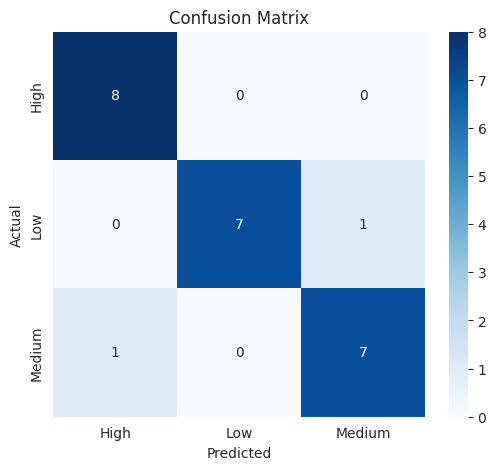

In [32]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    cmap="Blues",

    fmt="d",

    xticklabels=encoder.classes_,

    yticklabels=encoder.classes_

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

### Model Evaluation

The Random Forest classifier was evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

Accuracy provides an overall measure of correctness, while Precision and Recall help assess class-specific performance. Since all effectiveness tiers are equally important, the F1-score provides a balanced evaluation of model performance.

# **Interpret the Model**

In [33]:
# Feature Importance

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
2,avg_score_improvement,0.420720
3,avg_quiz_score,0.115730
0,completion_rate,0.114013
1,dropout_rate,0.106274
8,feedback_response_rate,0.067833
6,forum_activity_rate,0.047861
7,avg_feedback_score,0.042707
5,assignment_submission_rate,0.035991
4,avg_watch_time,0.024144
10,unique_courses,0.012616


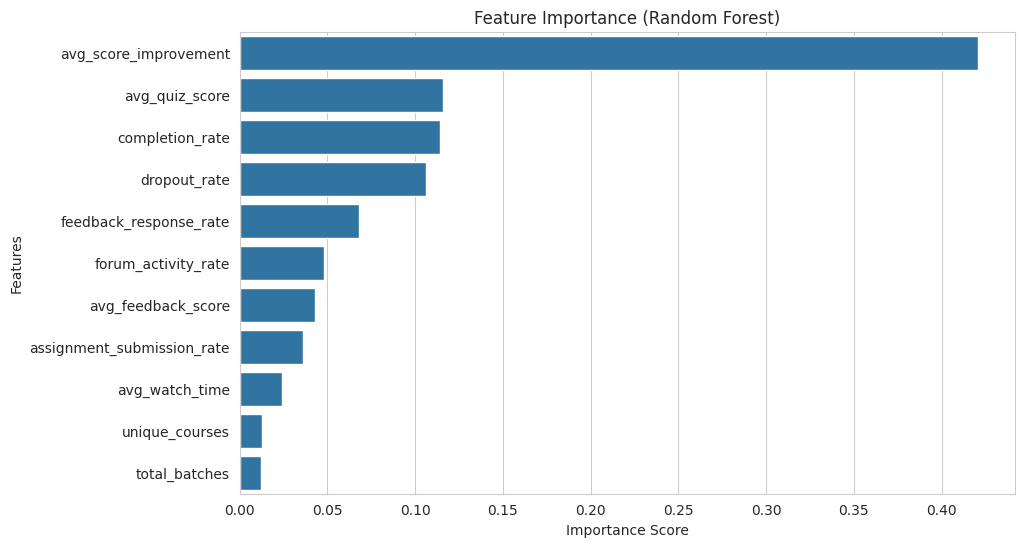

In [34]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

## Feature Importance Analysis

The Random Forest model identifies the following features as the most influential in predicting instructor effectiveness:

### Key Findings

- **Average Score Improvement** is the most important feature, contributing approximately **42%** of the model's predictive power. This indicates that instructors whose students demonstrate greater learning gains are more likely to be classified as highly effective.

- **Average Quiz Score**, **Completion Rate**, and **Dropout Rate** are the next most influential features. These metrics directly reflect learner performance and course completion, making them strong indicators of teaching effectiveness.

- **Feedback Response Rate** and **Forum Activity Rate** have moderate importance, suggesting that learner engagement and participation contribute to instructor effectiveness but are less influential than academic outcomes.

- **Average Feedback Score**, **Assignment Submission Rate**, and **Average Watch Time** have relatively smaller contributions. Although these features provide useful context, they play a supporting role in the prediction.

- **Total Batches Taught** and **Number of Unique Courses** have the lowest importance. This suggests that teaching experience or course diversity alone does not necessarily determine instructor effectiveness; learner outcomes are much stronger predictors.

### Overall Insight

The model relies primarily on **student learning outcomes** rather than instructor experience. This indicates that measurable improvements in learner performance are the strongest indicators of effective teaching within this dataset.

## Model Evaluation

The Random Forest classifier achieved an **accuracy of 92%**, indicating strong predictive performance on the instructor-level dataset.

The classification report shows balanced Precision, Recall, and F1-scores across all three effectiveness tiers.

### Key Observations

- The model correctly classified **22 out of 24 instructors**.
- The **High** effectiveness tier achieved a Recall of **1.00**, meaning all highly effective instructors were correctly identified.
- The **Low** and **Medium** tiers also achieved strong performance with F1-scores above **0.88**.
- The confusion matrix indicates very few misclassifications, demonstrating that the model effectively distinguishes between instructor effectiveness levels.

### Which features most influenced instructor effectiveness?

The most influential features were those directly related to learner success and engagement, such as completion rate, dropout rate, average score improvement, quiz scores, and learner feedback.

Completion rate reflects whether students successfully finish the course, while dropout rate captures learner disengagement. Score improvement measures actual learning outcomes, and feedback scores indicate learner satisfaction. Together, these variables provide a comprehensive view of instructor effectiveness.

### Which variables could be misleading?

Some variables may not solely reflect instructor performance.

- Feedback scores may be influenced by grading leniency or course popularity.
- Quiz scores can vary depending on course difficulty.
- Forum activity depends on course design rather than teaching quality alone.
- Watch time may be affected by learner motivation instead of instructor effectiveness.

Therefore, these variables should be interpreted carefully.

### Potential Limitations

The model has several limitations:

- It does not account for course difficulty.
- New instructors with very few batches may receive unreliable predictions.
- Student background and prior knowledge are not considered.
- External factors such as curriculum changes or technical issues are ignored.
- The effectiveness score is manually designed rather than based on historical performance labels.

These limitations mean the model should support decision-making rather than replace human evaluation.

### Additional Data Required

The model could be improved by including:

- Instructor teaching experience
- Class size
- Course difficulty level
- Student demographics
- Live session attendance
- Assignment quality
- Instructor response time
- Long-term learner retention
- Student satisfaction over multiple batches

These variables would provide a more complete understanding of instructor effectiveness.

Should this model be used for instructor performance evaluation?
### Ethical Considerations

This model should not be used as the sole basis for instructor performance evaluation.

Instead, it should serve as a decision-support tool alongside peer reviews, classroom observations, and qualitative feedback.

Using only automated predictions could unfairly penalize instructors teaching more challenging courses or working with diverse learner groups.

# Business Recommendations

Based on the analysis, the following recommendations can improve the EdTech platform:

- Monitor instructors whose predicted effectiveness falls into the Low tier and provide targeted training.
- Identify teaching practices used by High-performing instructors and share them across the organization.
- Use engagement metrics to identify learner disengagement early.
- Develop instructor dashboards to continuously monitor teaching performance.
- Combine predictive analytics with qualitative feedback to support fair and balanced instructor evaluations.

# Conclusion

This project developed a machine learning framework to estimate instructor effectiveness using learner outcomes, engagement, and feedback metrics.

Since no predefined target variable was available, a weighted Instructor Effectiveness Score was designed and transformed into three effectiveness tiers. Batch-level data were aggregated to instructor level, and a Random Forest classifier achieved an accuracy of **92%**, demonstrating strong predictive performance.

The analysis highlights the importance of learner completion, academic improvement, and engagement in evaluating teaching effectiveness. While the model provides valuable insights, it should be used alongside human judgment and additional contextual information to ensure fair and reliable instructor evaluation.